In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
from tqdm import tqdm

def smoothen_rdm(rdm_array, window=5):

    # if rdm_array is 3 dimensional, add a dimension near the 1st dimension
    if rdm_array.ndim == 3:
        rdm_array = rdm_array[np.newaxis, :, :, :]
    
    # Input shape: (n_participants, n_timepoints, n_features, n_features)
    n_participants, n_timepoints, n_features, _ = rdm_array.shape

    # Initialize an empty list to store the results for each participant
    smoothed_results = []

    for participant in range(n_participants):
        # Extract the RDMs for the current participant
        participant_rdms = rdm_array[participant]

        # Keep the first timepoint's RDM as is
        first_rdm = participant_rdms[0:1]  # Shape: (1, n_features, n_features)

        # Process the remaining timepoints
        remaining_rdms = participant_rdms[1:]

        # Calculate the number of complete groups (each with 'window' timepoints)
        num_groups = remaining_rdms.shape[0] // window

        # Reshape to group every 'window' timepoints together
        reshaped_array = remaining_rdms[:num_groups * window].reshape(num_groups, window, n_features, n_features)

        # Average each group along the second axis
        averaged_rdms = reshaped_array.mean(axis=1)  # Shape: (num_groups, n_features, n_features)

        # Concatenate the first RDM with the averaged RDMs
        smoothed_rdm = np.concatenate([first_rdm, averaged_rdms], axis=0)

        # Append the smoothed RDM for the current participant
        smoothed_results.append(smoothed_rdm)

    # Stack all participants' results into the final array
    result = np.stack(smoothed_results, axis=0)  # Shape: (n_participants, new_timepoints, n_features, n_features)



    return result

def compute_lower_bound(neural_rdms):
    n_participants, n_timepoints, n_objects, _ = neural_rdms.shape
    participant_correlations = np.zeros((n_participants, n_timepoints))
    indices = np.triu_indices(n_objects, k=1)
    
    for p in range(n_participants):
        for t in range(n_timepoints):
            participant_rdm = neural_rdms[p, t, :, :]
            # Compute the average of other participants
            others = np.delete(np.arange(n_participants), p)
            others_rdms = neural_rdms[others, t, :, :]
            average_others_rdm = np.mean(others_rdms, axis=0)
            
            # Get upper triangle
            participant_rdm_flat = participant_rdm[indices]
            average_others_rdm_flat = average_others_rdm[indices]
            
            # Compute Spearman correlation
            corr, _ = spearmanr(participant_rdm_flat, average_others_rdm_flat, nan_policy='omit')
            participant_correlations[p, t] = corr
    
    # Compute mean and std over participants at each timepoint
    mean_correlations = np.mean(participant_correlations, axis=0)  # shape (n_timepoints,)
    std_correlations = np.std(participant_correlations, axis=0)    # shape (n_timepoints,)
    
    return mean_correlations, std_correlations


In [17]:
path = "../output/cliphba_individual_cichy_official_v2/cichy/overall_rdms.npy"

model_rdms = np.load(path)
print(model_rdms.shape)

(3, 221, 118, 118)


In [18]:
meg_path = "./Data/Cichy/Cichy_MEG_RDM_Rescaled.npy"
meg_rdms = np.load(meg_path)

n_model_p = model_rdms.shape[0]

meg_rdms =  meg_rdms[:n_model_p]

if model_rdms.shape[1] < meg_rdms.shape[1]:
    window = (meg_rdms.shape[1]-1) // (model_rdms.shape[1] - 1)
    print(window)
    meg_rdms = smoothen_rdm(meg_rdms, window = window)
else:
    window = (model_rdms.shape[1]-1) // (meg_rdms.shape[1] - 1)
    print(window)


print(meg_rdms.shape)

5
(3, 221, 118, 118)


Calculating correlation for participant {p_id}: 100%|██████████| 3/3 [00:00<00:00,  3.40it/s]


(3, 221)


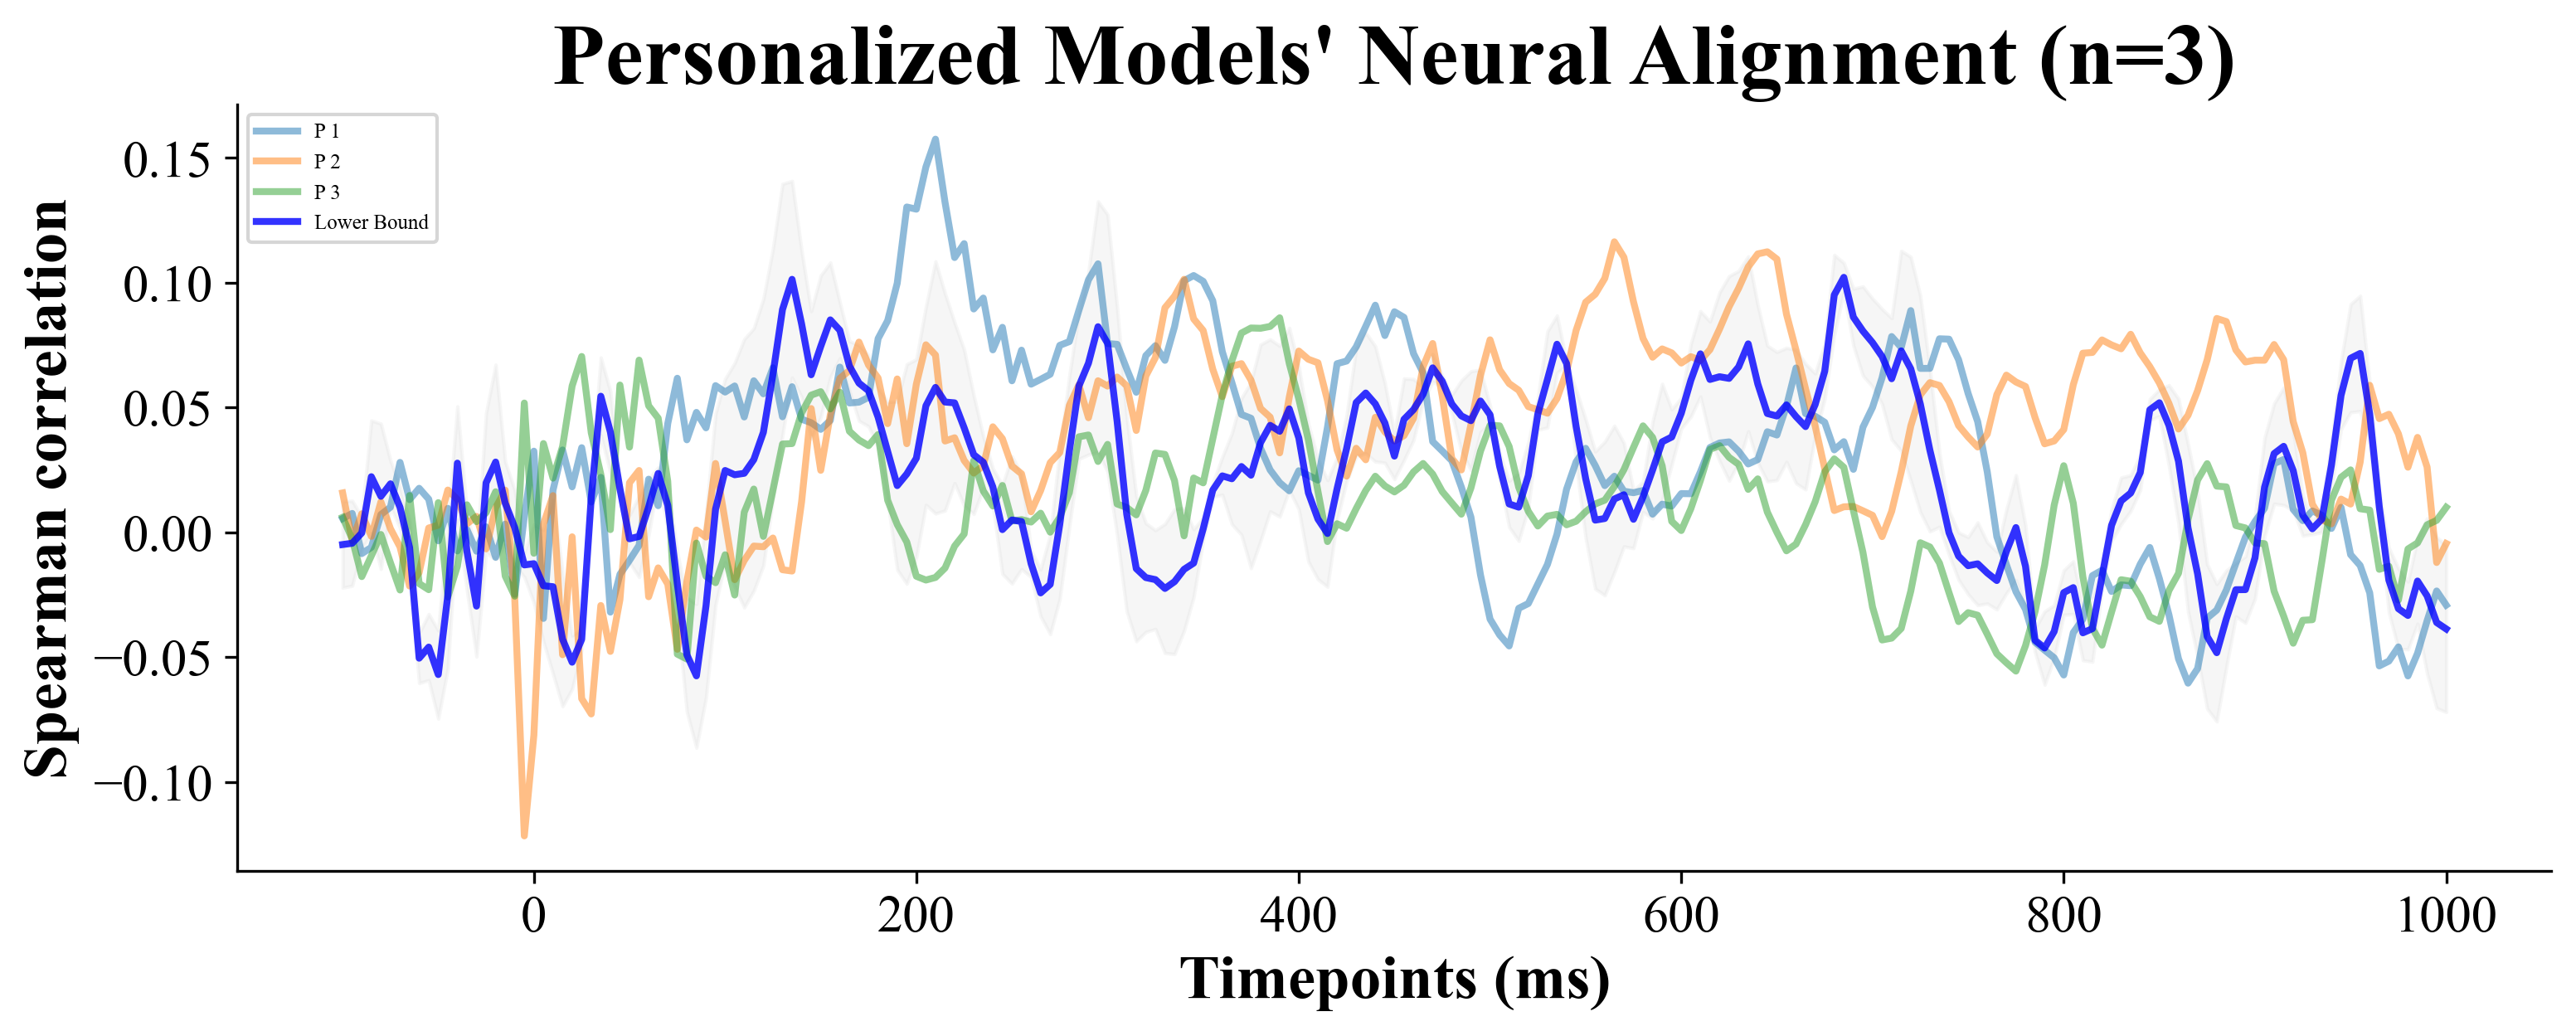

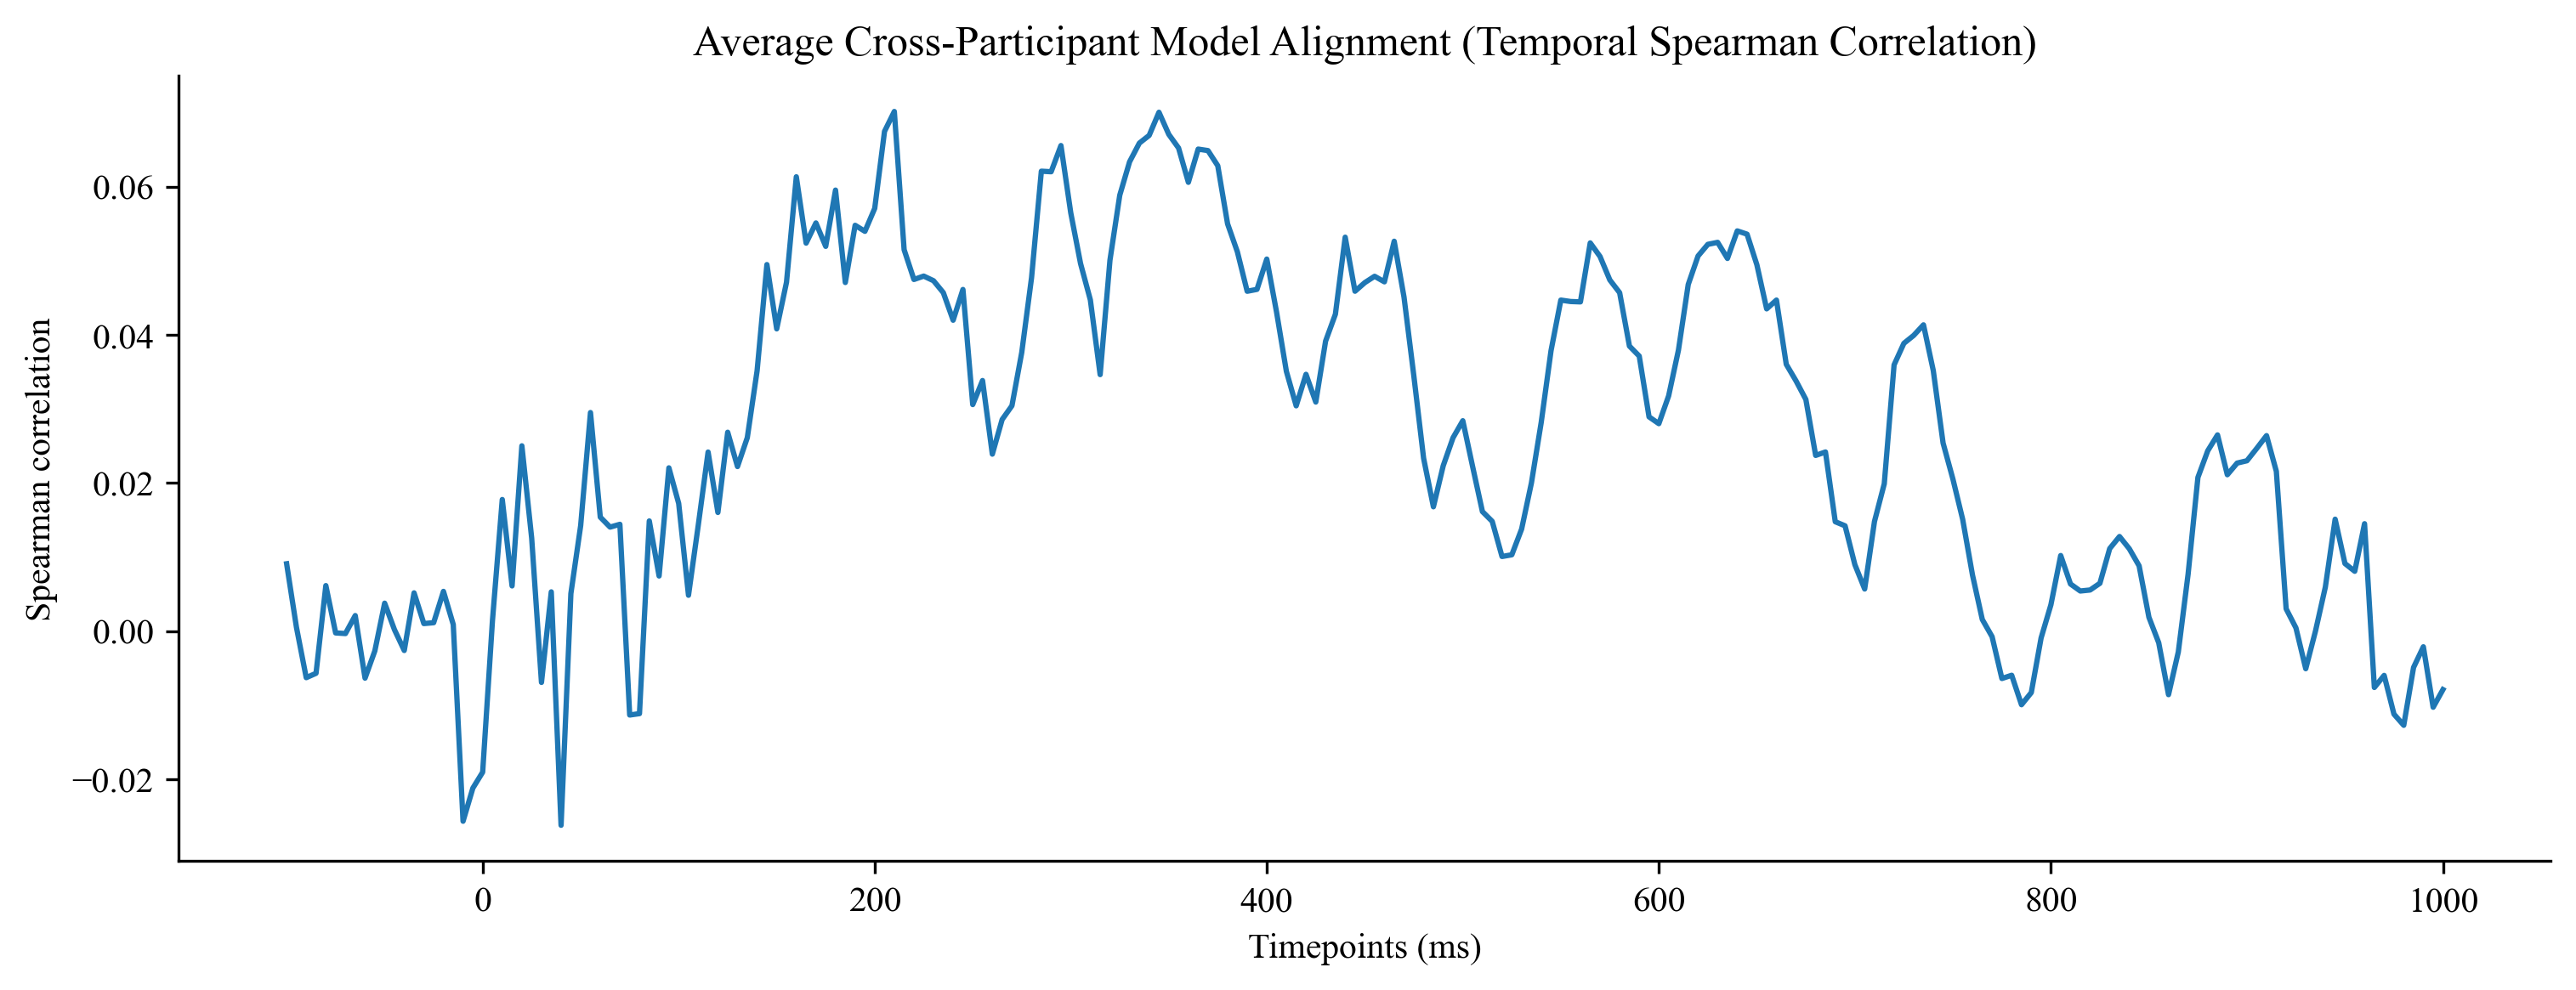

In [19]:
def calculate_dynamic_correlation(model_rdms, meg_rdms):
    # model_rdms, meg_rdms should be shaped [n_participants, n_timepoints, n_objects, n_objects]

    def calculate_participant_rdm_correlation(model_p_rdm, meg_p_rdm):
        # model_p_rdm, meg_p_rdm should be shaped [n_timepoints, n_objects, n_objects]
        n_timepoints = model_p_rdm.shape[0]

        participant_correlation = []
        for t in range(n_timepoints):
            model_rdm = model_p_rdm[t]
            meg_rdm = meg_p_rdm[t]

            corr, _ = spearmanr(model_rdm[np.triu_indices(model_rdm.shape[0], k=1)], meg_rdm[np.triu_indices(meg_rdm.shape[0], k=1)])
            participant_correlation.append(corr)

        return participant_correlation
    
    overall_correlation = []
    for p_id in tqdm(range(model_rdms.shape[0]), desc="Calculating correlation for participant {p_id}"):
        model_p_rdm = model_rdms[p_id]
        meg_p_rdm = meg_rdms[p_id]

        participant_correlation = calculate_participant_rdm_correlation(model_p_rdm, meg_p_rdm)
        overall_correlation.append(participant_correlation)

    return overall_correlation

# corr = np.array(calculate_dynamic_correlation(model_rdms[:, :, -18:, -18:], meg_rdms[:, :, -18:, -18:]))
corr = np.array(calculate_dynamic_correlation(model_rdms, meg_rdms))
# corr = np.array(calculate_dynamic_correlation(model_rdms[:, :, :100, :100], meg_rdms[:, :, :100, :100]))


# compute lower bound
mean_lower_bound, std_lower_bound = compute_lower_bound(meg_rdms)

timepoints = list(np.arange(-100, 1001, window))

print(corr.shape) # shape is [n_participants, n_timepoints]

# plot all individual participants dynamic correlations
plt.figure(figsize=(12, 4), dpi=300)

# times new roman for the plot
plt.rcParams["font.family"] = "Times New Roman"

# remove background
plt.gca().set_facecolor('none')

for p in range(corr.shape[0]):
    plt.plot(timepoints, corr[p], alpha=0.5,linewidth=2, label=f'P {p+1}')
    # plt.plot(timepoints, corr[p], alpha=0.5,linewidth=2)

plt.plot(timepoints, mean_lower_bound, label='Lower Bound', color='blue', linewidth=2, alpha=0.8)
plt.fill_between(timepoints, mean_lower_bound - std_lower_bound, mean_lower_bound + std_lower_bound, color='lightgrey', alpha=0.2)
plt.title(f"Personalized Models' Neural Alignment (n={corr.shape[0]})", fontsize=25, fontweight='bold')
plt.legend(fontsize=6, loc="upper left")
plt.xlabel('Timepoints (ms)', fontsize=18, fontweight='bold')
plt.ylabel('Spearman correlation', fontsize=18, fontweight='bold')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.savefig('./figures/individual_alignment.svg', format='svg', bbox_inches='tight', transparent=True) 

mean_corr = np.mean(corr, axis=0)

plt.figure(figsize=(12, 4), dpi=300)
plt.plot(timepoints, mean_corr)
plt.title('Average Cross-Participant Model Alignment (Temporal Spearman Correlation)')
plt.xlabel('Timepoints (ms)')
plt.ylabel('Spearman correlation')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
# plt.savefig('./figures/average_individual_alignment.svg', format='svg', facecolor='none', edgecolor='none')

(3, 221, 118, 118) (3, 221, 118, 118)
(3, 221, 6903) (3, 221, 6903)
(3, 1525563) (3, 1525563)
(3, 3) (3, 3)


C:\Users\BrainInspired\AppData\Local\Temp\ipykernel_43808\3836810872.py:59: RuntimeWarning: divide by zero encountered in log10
  plt.text(-0.15, -0.15, f"Spearman correlation: {corr:.3f}\n{'p < 1e-' + str(int(-np.floor(np.log10(p)))) if p < 1e-3 else f'p = {p:.3f}'}", horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=20, fontweight='bold')


OverflowError: cannot convert float infinity to integer

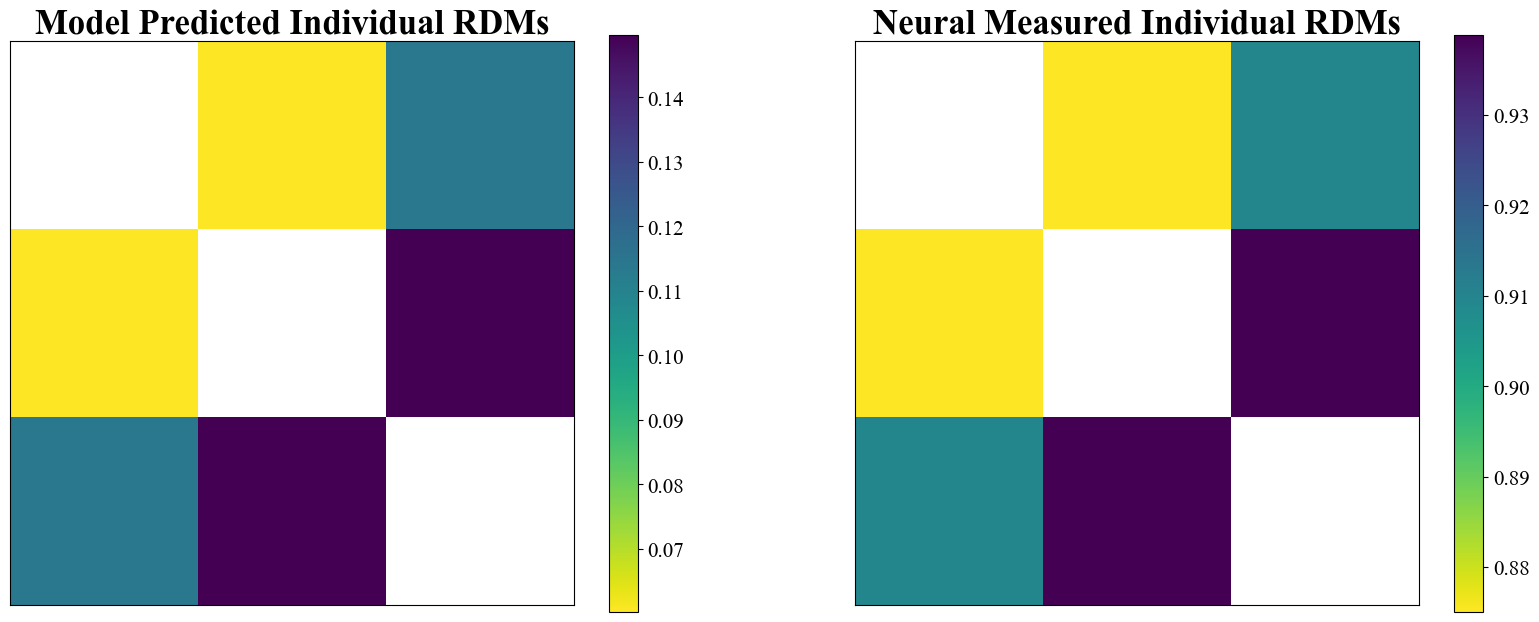

In [20]:
def compute_individual_rdm(model_rdms, neural_rdms):
    # model_rdms, neural_rdms should be shaped [n_participants, n_timepoints, n_objects, n_objects]

    print(model_rdms.shape, neural_rdms.shape)

    # Get the indices of the upper triangle, excluding the diagonal

    # Flatten the RDMs along the last 2 dimensions using the upper triangle indices
    upper_tri_indices = np.triu_indices(model_rdms.shape[-1], k=1)
    model_rdms_flat = model_rdms[:, :, upper_tri_indices[0], upper_tri_indices[1]]
    neural_rdms_flat = neural_rdms[:, :, upper_tri_indices[0], upper_tri_indices[1]]
    
    print(model_rdms_flat.shape, neural_rdms_flat.shape)

    model_rdms_flat = model_rdms_flat.reshape(model_rdms.shape[0], -1)
    neural_rdms_flat = neural_rdms_flat.reshape(neural_rdms.shape[0], -1)

    print(model_rdms_flat.shape, neural_rdms_flat.shape)

    # Compute the Pearson correlation distance between participants
    model_ind_rdm = 1 - np.corrcoef(model_rdms_flat)
    neural_ind_rdm = 1 - np.corrcoef(neural_rdms_flat)

    print(model_ind_rdm.shape, neural_ind_rdm.shape)


    # plot
    plt.figure(figsize=(20, 15))

    np.fill_diagonal(model_ind_rdm, np.nan)
    np.fill_diagonal(neural_ind_rdm, np.nan)
    

    plt.subplot(1, 2, 1)
    plt.imshow(model_ind_rdm, cmap='viridis_r')
    # plt.xlabel(f'Models (n={neural_ind_rdm.shape[0]})', fontsize=20, fontweight='bold')
    # plt.ylabel(f'Models (n={neural_ind_rdm.shape[0]})', fontsize=20, fontweight='bold')
    plt.xticks([])
    plt.yticks([])
    cbar = plt.colorbar(shrink=0.5)
    cbar.ax.tick_params(labelsize=15)
    plt.title('Model Predicted Individual RDMs', fontsize=25, fontweight='bold')
    plt.subplot(1, 2, 2)
    plt.imshow(neural_ind_rdm, cmap='viridis_r')
    # plt.xlabel(f'Participants (n={neural_ind_rdm.shape[0]})', fontsize=20, fontweight='bold')
    # plt.ylabel(f'Participants (n={neural_ind_rdm.shape[0]})', fontsize=20, fontweight='bold')
    plt.xticks([])
    plt.yticks([])
    cbar = plt.colorbar(shrink=0.5)
    cbar.ax.tick_params(labelsize=15)
    plt.title('Neural Measured Individual RDMs', fontsize=25, fontweight='bold')


    # Compute the Spearman correlation between the two RDMs
    corr, p = spearmanr(model_ind_rdm[np.triu_indices(model_ind_rdm.shape[0], k=1)], neural_ind_rdm[np.triu_indices(neural_ind_rdm.shape[0], k=1)])

    # print(f"Spearman correlation between model and neural RDMs: {corr}, p-value: {p}")

    plt.text(-0.15, -0.15, f"Spearman correlation: {corr:.3f}\n{'p < 1e-' + str(int(-np.floor(np.log10(p)))) if p < 1e-3 else f'p = {p:.3f}'}", horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=20, fontweight='bold')

    plt.savefig('./figures/individual_rdm.svg', format='svg', facecolor='none', edgecolor='none', transparent=True, bbox_inches='tight')

    # print(model_ind_rdm)



excluding_index = []
if excluding_index !=[]: 
    model_rdms = np.delete(model_rdms, excluding_index, axis=0)
    meg_rdms = np.delete(meg_rdms, excluding_index, axis=0)



compute_individual_rdm(model_rdms, meg_rdms)

(2, 221, 18, 18) (2, 221, 18, 18)
(2, 221, 153) (2, 221, 153)
(2, 33813) (2, 33813)
(2, 2) (2, 2)


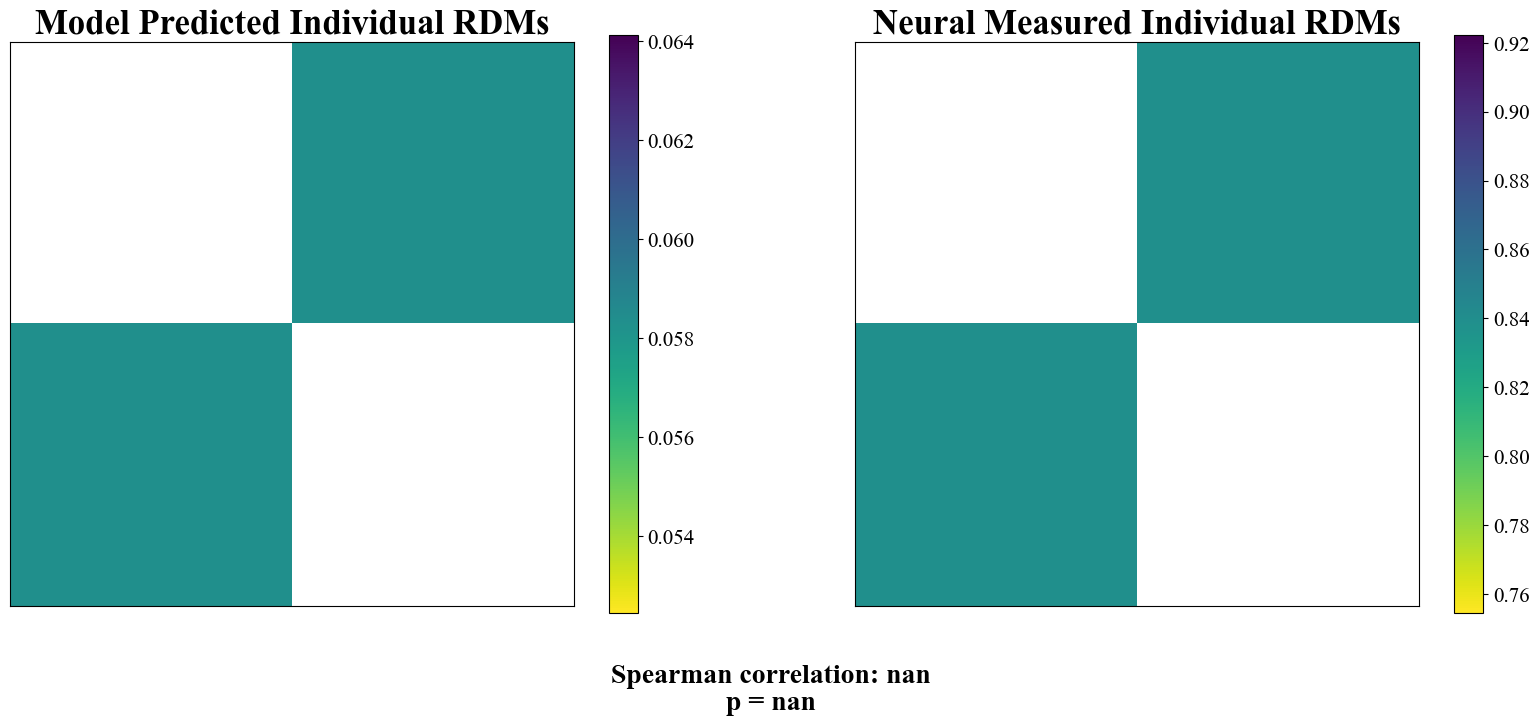

In [ ]:
compute_individual_rdm(model_rdms[:, :, -18:, -18:], meg_rdms[:, :, -18:, -18:])
# compute_individual_rdm(model_rdms[:, :, :100, :100], meg_rdms[:, :, :100, :100])

When do people diverge?

In [12]:
def plot_timepoint_rdms(diverge_rdms, vmax = 1, vmin = 0, title = 'Timepoint-by-Timepoint RDM Plot'):
    """
    Processes the input RDM array and plots the timepoint-by-timepoint RDM plot.
    
    Parameters:
        diverge_rdms (np.ndarray): Input array with shape (n_participants, n_timepoints, n_objects, n_objects)
    
    Returns:
        np.ndarray: The computed timepoint-by-timepoint RDM matrix (time_rdm).
    """
    # Reshape to (1101, 15, 118, 118)
    reshaped_rdms = diverge_rdms.transpose(1, 0, 2, 3)  # Bring the time dimension to the front
    
    # Get the upper triangle indices of a single RDM
    n_objects = reshaped_rdms.shape[2]
    triu_indices = np.triu_indices(n_objects, k=1)
    
    # Flatten the last two dimensions using the upper triangle
    flattened_rdms = reshaped_rdms[:, :, triu_indices[0], triu_indices[1]]  # Shape: (timepoints, participants, n_upper_indices)
    
    # Flatten the remaining last 2 dimensions into a long vector
    long_vector_rdms = flattened_rdms.reshape(reshaped_rdms.shape[0], -1)  # Shape: (timepoints, n_d_long_vector)
    
    # Compute the timepoint-by-timepoint RDM matrix
    time_rdm = 1 - np.corrcoef(long_vector_rdms)
    # # replace the diagonal with nan
    # np.fill_diagonal(time_rdm, np.nan)
    
    # Plot the timepoint-by-timepoint RDM plot
    # plt.figure(figsize=(10, 8))
    plt.imshow(time_rdm, cmap='viridis_r', vmax = vmax, vmin=vmin)
    # plt.colorbar(label='Dissimilarity (1 - Correlation)')
    plt.xlabel('Time (ms)')
    plt.ylabel('Time (ms)')
    plt.title(title)
    plt.show()
    
    return time_rdm


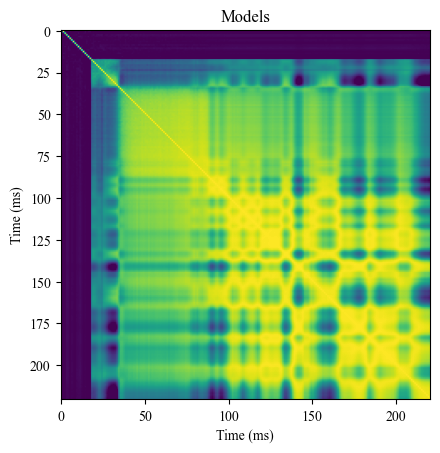

In [ ]:
diverge_rdms = model_rdms.copy()
diverge_rdms.shape # shape (n_participants, n_timepoints, n_objects, n_objects) (15, 1101, 118, 118)

p_time_rdm = plot_timepoint_rdms(diverge_rdms, vmax=1, vmin=0, title = "Models")

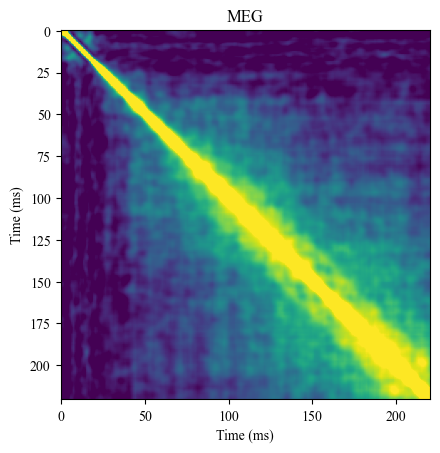

In [ ]:
meg_time_rdm = plot_timepoint_rdms(meg_rdms, vmax=1, vmin=0.5, title = "MEG")

(2, 221)
(2,)


Text(0.5, 1.0, 'Mean RDM Distance for each Participant')

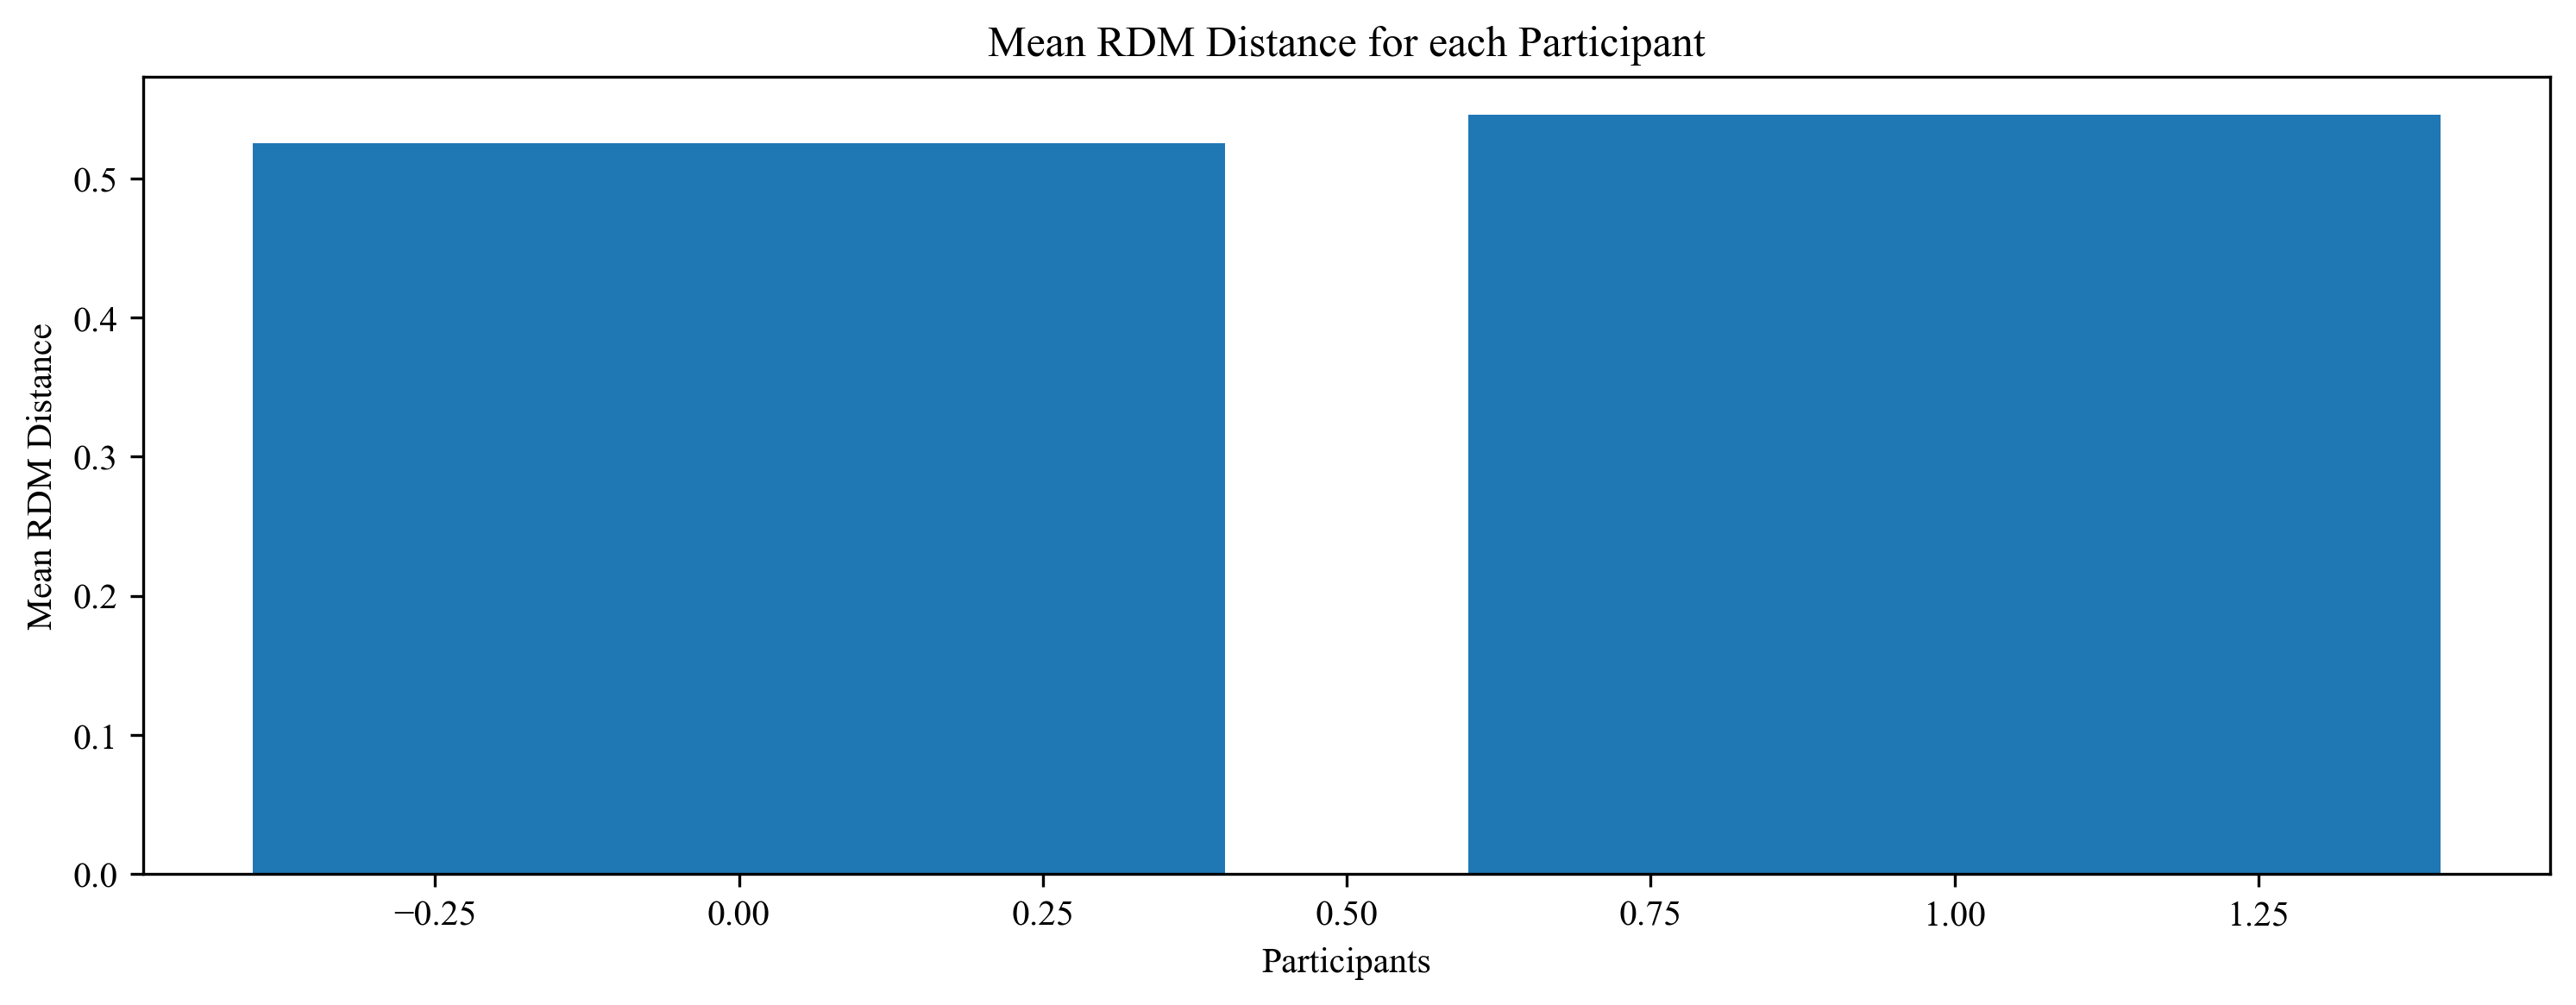

In [ ]:
meg_rdms.shape

# find the mean all RDM distances for each participants averaged on tiempoints

p_overall_dist = []
for p in range(model_rdms.shape[0]):
    p_dist = []
    for t in range(model_rdms.shape[1]):
        p_dist.append(np.mean(model_rdms[p, t]))
    p_overall_dist.append(p_dist)
    

p_overall_dist = np.array(p_overall_dist)
print(p_overall_dist.shape)

p_mean_dist = np.mean(p_overall_dist, axis=1)
print(p_mean_dist.shape)

# plot bar plot 

plt.figure(figsize=(12, 4), dpi=300)
plt.bar(np.arange(p_mean_dist.shape[0]), p_mean_dist)
plt.xlabel('Participants')
plt.ylabel('Mean RDM Distance')
plt.title('Mean RDM Distance for each Participant')